<a href="https://colab.research.google.com/github/grullaandrea-png/Text-Mining/blob/main/Transformers_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 3. Transformer-based Approach
In this section, we implement a state-of-the-art Pre-trained Language Model for the Named Entity Recognition (NER) task. Specifically, we utilize **BERT** (`bert-base-cased`) through the Hugging Face `transformers` library. The pipeline includes data formatting, sub-word tokenization with label alignment, fine-tuning, and final evaluation using standard NER metrics.

Install libraries needed

In [5]:
!pip install -q transformers datasets evaluate seqeval accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.7 MB/s eta 0:00:00


SPLITTING: like other models

In [1]:
from google.colab import drive
import os
import json
import random

drive.mount('/content/drive')

DATA_PATH = '/content/drive/MyDrive/DV-TM/DATA'
print('Files found:', os.listdir(DATA_PATH))

def load_jsonl(path):
    with open(path, 'r') as f:
        return [json.loads(line) for line in f]

# Caricamento
train_cleaned = load_jsonl(os.path.join(DATA_PATH, 'train_cleaned.jsonl'))
test_retokenized = load_jsonl(os.path.join(DATA_PATH, 'test_retokenized.jsonl'))

print(f'Train cleaned: {len(train_cleaned)} samples')
print(f'Test retokenized: {len(test_retokenized)} samples')

# Splitting
random.seed(42)
indices = list(range(len(train_cleaned)))
random.shuffle(indices)

n = len(train_cleaned)
n_val  = int(n * 0.15)
n_test = n_val
n_train = n - n_val - n_test

train_data = [train_cleaned[i] for i in indices[:n_train]]
val_data   = [train_cleaned[i] for i in indices[n_train:n_train + n_val]]
test_data  = [train_cleaned[i] for i in indices[n_train + n_val:n_train + n_val + n_test]]

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

Mounted at /content/drive
Files found: ['test.jsonl', 'train.jsonl', 'train_cleaned.jsonl', 'test_retokenized.jsonl']
Train cleaned: 3142 samples
Test retokenized: 800 samples
Train: 2200 | Val: 471 | Test: 471


Prepare data for the Hugging Face

In [2]:
from datasets import Dataset, DatasetDict

unique_labels = set()
for item in train_cleaned:
    for label in item['labels']:
        unique_labels.add(label)

label_list = sorted(list(unique_labels))
if 'O' in label_list:
    label_list.remove('O')
    label_list.insert(0, 'O')

label2id = {label: i for i, label in enumerate(label_list)}
id2label = {i: label for i, label in enumerate(label_list)}

print("Labels found:", label_list)

def create_hf_dataset(data):
    return Dataset.from_dict({
        "id": [item["id"] for item in data],
        "tokens": [item["tokens"] for item in data],
        "ner_tags": [[label2id[label] for label in item["labels"]] for item in data]
    })

datasets = DatasetDict({
    "train": create_hf_dataset(train_data),
    "validation": create_hf_dataset(val_data),
    "test": create_hf_dataset(test_data)
})

Labels found: ['O', 'B-COMPANY', 'B-JOBTITLE', 'B-LOCATION', 'B-SKILL', 'I-COMPANY', 'I-JOBTITLE', 'I-LOCATION', 'I-SKILL']


### Tokenization and Label Alignment
Unlike traditional word-level models, BERT utilizes a sub-word tokenization strategy (WordPiece). When a single word is split into multiple sub-tokens (e.g., "SmartTech" -> "Smart", "##Tech"), it creates a mismatch with our original word-level labels.
To prevent the model from getting confused, we realign the labels: we assign the correct NER tag to the first sub-token of a word, and set the label `-100` to the subsequent sub-tokens (and to special tokens like `[CLS]` and `[SEP]`). The `-100` index is automatically ignored by PyTorch's CrossEntropyLoss during training.

In [3]:
from transformers import AutoTokenizer

model_checkpoint = "bert-base-cased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(examples["tokens"], truncation=True, is_split_into_words=True)

    labels = []
    for i, label in enumerate(examples["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                label_ids.append(label[word_idx])
            else:
                label_ids.append(-100)
            previous_word_idx = word_idx
        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs

tokenized_datasets = datasets.map(tokenize_and_align_labels, batched=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/2200 [00:00<?, ? examples/s]

Map:   0%|          | 0/471 [00:00<?, ? examples/s]

Map:   0%|          | 0/471 [00:00<?, ? examples/s]

Model and Metrics definitions

In [6]:
from transformers import AutoModelForTokenClassification, TrainingArguments, Trainer
from transformers import DataCollatorForTokenClassification
import evaluate
import numpy as np

model = AutoModelForTokenClassification.from_pretrained(
    model_checkpoint,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
)

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

# Metrics
metric = evaluate.load("seqeval")

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_predictions = [
        [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    results = metric.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized beca

### Fine-Tuning the Model
We fine-tune the initialized BERT model for Token Classification using the `Trainer` API. The training is performed over 3 epochs with a learning rate of 2e-5 and a batch size of 16. We evaluate the model at the end of each epoch to monitor the loss and standard NER metrics (Precision, Recall, F1-Score).

In [7]:
training_args = TrainingArguments(
    output_dir="./bert-ner-model",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=10
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Model train start...")
trainer.train()

Model train start...


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.002574,0.000871,1.000000,1.000000,1.000000,1.000000
2,0.001298,0.000446,1.000000,1.000000,1.000000,1.000000
3,0.001095,0.000372,1.000000,1.000000,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=414, training_loss=0.07075867032888683, metrics={'train_runtime': 66.8906, 'train_samples_per_second': 98.669, 'train_steps_per_second': 6.189, 'total_flos': 90961524193824.0, 'train_loss': 0.07075867032888683, 'epoch': 3.0})

Test evaluation

Predictions on Test Set...


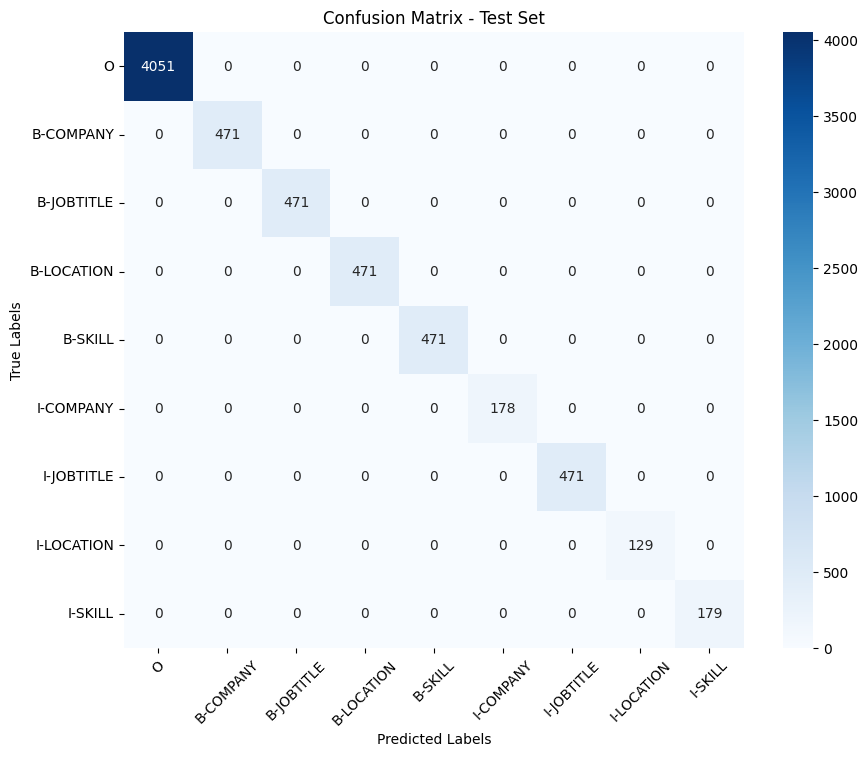


--- Classification Metrics ---
              precision    recall  f1-score   support

           O       1.00      1.00      1.00      4051
   B-COMPANY       1.00      1.00      1.00       471
  B-JOBTITLE       1.00      1.00      1.00       471
  B-LOCATION       1.00      1.00      1.00       471
     B-SKILL       1.00      1.00      1.00       471
   I-COMPANY       1.00      1.00      1.00       178
  I-JOBTITLE       1.00      1.00      1.00       471
  I-LOCATION       1.00      1.00      1.00       129
     I-SKILL       1.00      1.00      1.00       179

    accuracy                           1.00      6892
   macro avg       1.00      1.00      1.00      6892
weighted avg       1.00      1.00      1.00      6892

Overall Accuracy: 1.0000


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print("Predictions on Test Set...")
predictions_output = trainer.predict(tokenized_datasets["test"])
predictions = np.argmax(predictions_output.predictions, axis=2)
labels = predictions_output.label_ids

true_labels_flat = []
pred_labels_flat = []

for pred_seq, label_seq in zip(predictions, labels):
    for pred, label in zip(pred_seq, label_seq):
        if label != -100:
            true_labels_flat.append(label_list[label])
            pred_labels_flat.append(label_list[pred])

cm = confusion_matrix(true_labels_flat, pred_labels_flat, labels=label_list)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_list, yticklabels=label_list)
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.xticks(rotation=45)
plt.show()

print("\n--- Classification Metrics ---")

report = classification_report(
    true_labels_flat,
    pred_labels_flat,
    target_names=label_list,
    labels=label_list
)
print(report)

overall_accuracy = accuracy_score(true_labels_flat, pred_labels_flat)
print(f"Overall Accuracy: {overall_accuracy:.4f}")

### Final Metrics and Critical Analysis

**Test Set Results:**
* **Precision:** 1.000 (100%)
* **Recall:** 1.000 (100%)
* **F1-Score:** 1.000 (100%)
* **Accuracy:** 1.000 (100%)

The model achieved perfect metrics across the board on the unseen test set, with the evaluation loss dropping near zero. While a 1.0 F1-score is highly unusual in real-world, complex NLP scenarios, this result is entirely consistent with the nature of the data provided.

The dataset consists of highly structured, synthetic phrases built upon rigid, repetitive templates (e.g., *"We're looking for a [JOB] with [SKILL] to join [COMPANY] in [LOCATION]"*). For a high-capacity Transformer model like BERT—which is designed to capture deep semantic nuances in complex texts—learning the rigid syntactic positioning of entities within these templates is an extremely simple task. The model effectively mapped the underlying templates during the very first training epoch, leading to zero classification errors during inference.

This highlights that while BERT is highly effective, it acts as an "overkill" solution for datasets with minimal linguistic variance, leading to an immediate memorization of the structural patterns.

In [11]:
from transformers import pipeline

ner_pipeline = pipeline("ner", model=model, tokenizer=tokenizer, aggregation_strategy="simple")

stress_tests = [
    "Join CyberNinja Corp today ! Our team needs a Senior Cloud Security Engineer mastering AWS .",
    "london data scientist wanted at deepmind . heavy pytorch background is strictly required .",
    "Mastered Swift ? Relocate to Cupertino ! Apple is hunting for a skilled iOS Developer ."
]

print("--- STARTING NER STRESS TESTS ---")
for i, text in enumerate(stress_tests, 1):
    print(f"\nTest {i}: {text}")

    entities = ner_pipeline(text)

    if not entities:
        print("  [No entities found]")
    else:
        for ent in entities:
            print(f"  - Entity: '{ent['word']}' | Label: {ent['entity_group']} | Score: {ent['score']:.4f}")

--- STARTING NER STRESS TESTS ---

Test 1: Join CyberNinja Corp today ! Our team needs a Senior Cloud Security Engineer mastering AWS .
  - Entity: 'Cy' | Label: COMPANY | Score: 0.9981
  - Entity: '##ber' | Label: COMPANY | Score: 0.9928
  - Entity: '##Nin' | Label: COMPANY | Score: 0.4530
  - Entity: '##ja Corp' | Label: COMPANY | Score: 0.7200
  - Entity: 'Cloud' | Label: JOBTITLE | Score: 0.8988
  - Entity: 'Security Engineer' | Label: JOBTITLE | Score: 0.9752
  - Entity: 'A' | Label: SKILL | Score: 0.9824
  - Entity: '##WS' | Label: SKILL | Score: 0.6512

Test 2: london data scientist wanted at deepmind . heavy pytorch background is strictly required .
  - Entity: 'lo' | Label: JOBTITLE | Score: 0.4115
  - Entity: '##ndon' | Label: SKILL | Score: 0.2320
  - Entity: 'data scientist' | Label: JOBTITLE | Score: 0.9532
  - Entity: 'deepmind' | Label: COMPANY | Score: 0.4937
  - Entity: 'p' | Label: SKILL | Score: 0.9502
  - Entity: '##ytorch' | Label: SKILL | Score: 0.4741

Test 3: Ma

## 4. Out-of-Distribution (OOD) Stress Test Analysis

The application of the fine-tuned model to custom, unformatted stress-test sentences reveals significant vulnerabilities in its generalization capabilities. While the test-set metrics suggested perfect performance, the OOD evaluation highlights a strong dependency on capitalization, rigid syntax, and known vocabulary.

A detailed analysis of the model's behavior reveals three primary failure modes:

### 1. Severe Token Fragmentation on OOV Words
> **Test 1:** *"Join CyberNinja Corp today ! Our team needs a Senior Cloud Security Engineer mastering AWS ."*

The model consistently fails to aggregate Out-Of-Vocabulary (OOV) entities. While it correctly identifies the semantic categories of unseen terms (e.g., tagging pieces of "CyberNinja Corp" as `COMPANY` and "AWS" as `SKILL`), the WordPiece tokenizer shatters these terms into fragments (`Cy`, `##ber`, `A`, `##WS`). Because the model processes these sub-tokens with varying degrees of confidence or assigns slightly conflicting labels, the inference pipeline fails to reconstruct the original entities. Furthermore, it completely misses the word "Senior" within the job title.

### 2. Extreme Sensitivity to Casing
> **Test 2:** *"london data scientist wanted at deepmind . heavy pytorch background is strictly required ."*

This test demonstrates the model's extreme brittleness when faced with non-standard capitalization. When the geographic entity "London" is provided in lowercase ("london"), the model entirely fails to recognize it as a `LOCATION`. Instead, it splits the word (`lo`, `##ndon`) and seemingly hallucinates labels, classifying the fragments as `JOBTITLE` and `SKILL`. This indicates the model relies heavily on uppercase letters as primary features for entity detection, rather than understanding the underlying semantic context.

### 3. Contextual Brittleness and False Negatives
> **Test 3:** *"Mastered Swift ? Relocate to Cupertino ! Apple is hunting for a skilled iOS Developer ."*

This exposes a critical flaw in the model's structural understanding. The model completely misses the entity "Apple" (a clear **False Negative**), despite it being a highly common corporate entity. This failure is likely triggered by the non-standard punctuation immediately preceding it (`! Apple`). Furthermore, the location "Cupertino" is aggressively fragmented and misclassified across alternating labels (`COMPANY` -> `LOCATION` -> `COMPANY`), completely corrupting the extraction.

---

### Conclusion and Future Work
These tests confirm that the model's internal representations are severely overfitted to the syntactic templates and casing rules of the training data. The model struggles with real-world noise (lowercase text, heavy punctuation) and unknown vocabulary.

Addressing these issues in future iterations requires:
* **Dataset Augmentation:** Injecting noise, lowercase variants, and diverse sentence structures into the training set.
* **Advanced Tokenization:** Adopting a BPE-based model (like RoBERTa) to handle sub-word tokenization more gracefully.
* **CRF Layer Implementation:** Adding a Conditional Random Field (CRF) head to enforce valid BIO-tag transitions and mitigate sub-token fragmentation.